In [183]:
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [184]:
df_original = pd.read_excel(
    'bbdd/Base Datos con categorias agrupadas.xlsx',
    header=1,
    decimal=',',
    )
df = df_original.copy()

num_var= ['Creatininapre', 'Estanciahospitalariacalculada', 'Htopre']
X_num = df[num_var]
X_num = X_num.apply(pd.to_numeric, errors='coerce')

cat_binary_var = ['ComplicacionesMACE', 'ComplicacionesTODAS']
X_cat_binary = df[cat_binary_var]
X_cat_binary = X_cat_binary.apply(pd.to_numeric, errors='coerce')

cat_points_var = ['Edmonton']
X_cat_points = df[cat_points_var]

X = pd.concat([X_num, X_cat_binary, X_cat_points], axis=1)

X = X.fillna(X.mode().iloc[0])

y = df['Mortalidad30']

In [185]:
# --- 1. CARGAR MODELO Y DATOS ---

model = joblib.load("model.joblib")

# Extraer el modelo final del pipeline (sin SMOTE ya que es solo para entrenamiento)
preprocessor = model.named_steps['preprocessor']
final_model = model.named_steps['regressor']

# Crear una función wrapper que combine el preprocesamiento con el modelo
def model_predict(X):
    X_transformed = preprocessor.transform(X)
    return final_model.predict_proba(X_transformed)


In [381]:

# --- 2. APLICAR SHAP EXPLAINER ---
# Usamos el TreeExplainer de SHAP (óptimo para XGBoost)
# Crear el explicador SHAP usando el wrapper
explainer = shap.Explainer(model_predict, X)
shap_values = explainer(X)


In [ ]:
#Save the explainer includin associated functions (model_predict)
joblib.dump(explainer, 'explainer.joblib')


['explainer.joblib']

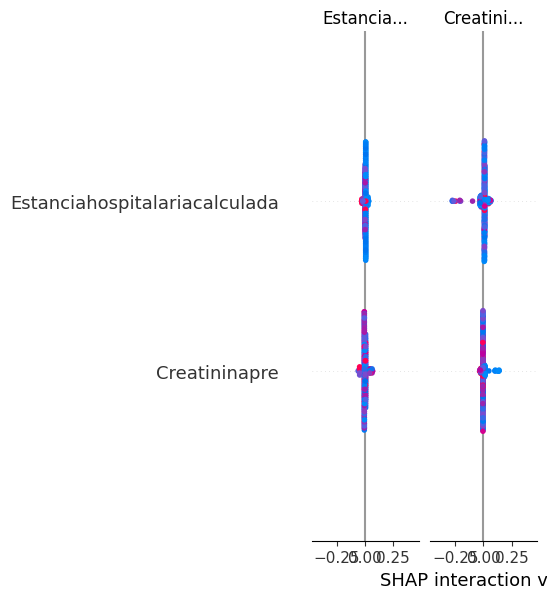

In [338]:
shap.summary_plot(shap_values, X, plot_type="bar", max_display=len(X.columns), show=False)
plt.show()

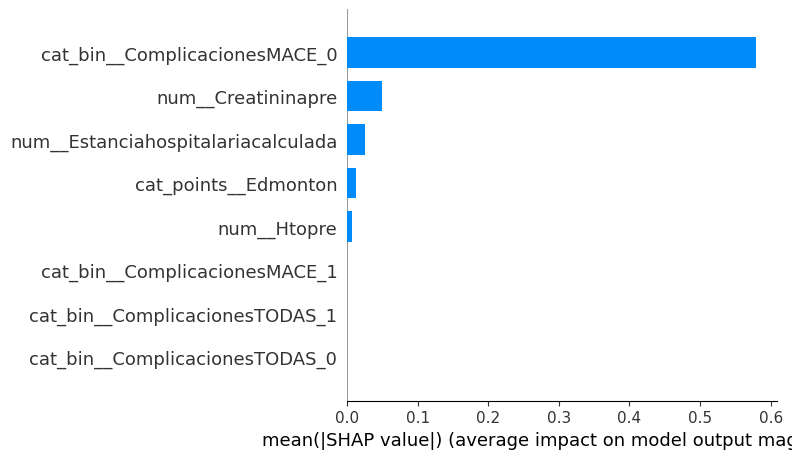

In [367]:
# ...código existente...
X_transformed = preprocessor.transform(X)
feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

explainer = shap.Explainer(final_model, X_transformed_df)
shap_values = explainer(X_transformed_df)

shap.summary_plot(shap_values, X_transformed_df, plot_type="bar", max_display=len(feature_names), show=False)
plt.show()
# ...código existente...

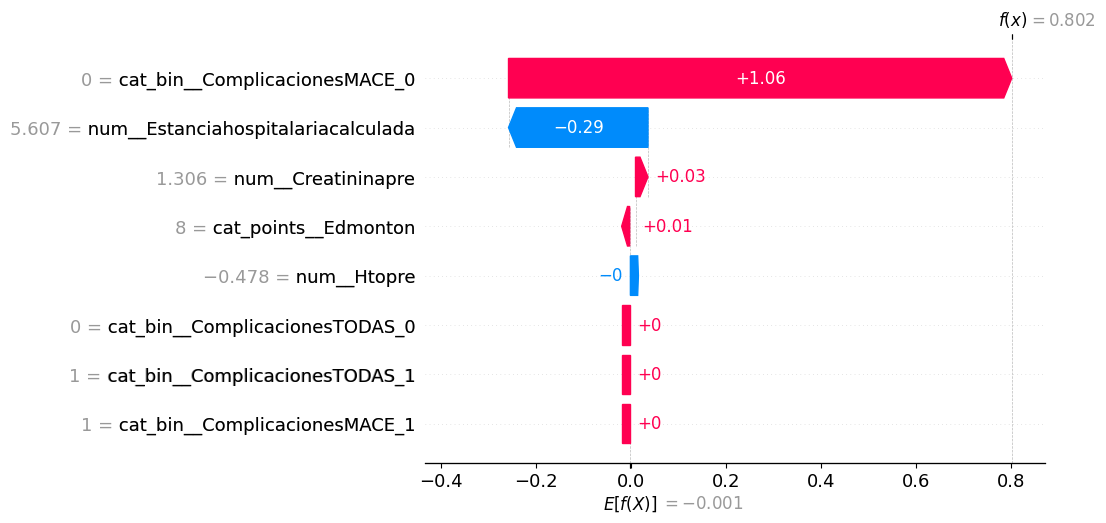

In [370]:
import shap

# 1. Explainer con TreeExplainer
explainer = shap.TreeExplainer(final_model)

# 2. SHAP values para todos o para un paciente
shap_values = explainer(X_transformed_df)

# 3. Waterfall plot para el primer paciente
shap.plots.waterfall(shap_values[0], max_display=10)
plt.show()

In [353]:
#Save the explainer
joblib.dump(explainer, 'explainer.joblib')

['explainer.joblib']

In [368]:
# Verificación de datos y valores SHAP
print("Verificación de datos:")
print("="*50)

# Verificar que todas las características están presentes
print(f"Características en X: {list(X.columns)}")
print(f"Forma de X: {X.shape}")

# Verificar valores SHAP para cada característica
for i, feature in enumerate(X.columns):
    if len(shap_values.shape) > 2:
        shap_vals = shap_values[:, i, 1].values  # Clase positiva
    else:
        shap_vals = shap_values[:, i].values
    
    print(f"{feature}:")
    print(f"  - Min SHAP: {shap_vals.min():.6f}")
    print(f"  - Max SHAP: {shap_vals.max():.6f}")
    print(f"  - Mean |SHAP|: {np.abs(shap_vals).mean():.6f}")
    print(f"  - Std SHAP: {shap_vals.std():.6f}")
    print()

Verificación de datos:
Características en X: ['Creatininapre', 'Estanciahospitalariacalculada', 'Htopre', 'ComplicacionesMACE', 'ComplicacionesTODAS', 'Edmonton']
Forma de X: (325, 6)
Creatininapre:
  - Min SHAP: -0.178438
  - Max SHAP: 0.024843
  - Mean |SHAP|: 0.006741
  - Std SHAP: 0.022285

Estanciahospitalariacalculada:
  - Min SHAP: -0.601883
  - Max SHAP: 0.151639
  - Mean |SHAP|: 0.048919
  - Std SHAP: 0.099814

Htopre:
  - Min SHAP: -0.166883
  - Max SHAP: 0.154069
  - Mean |SHAP|: 0.025493
  - Std SHAP: 0.043227

ComplicacionesMACE:
  - Min SHAP: 0.000000
  - Max SHAP: 0.000000
  - Mean |SHAP|: 0.000000
  - Std SHAP: 0.000000

ComplicacionesTODAS:
  - Min SHAP: 0.000000
  - Max SHAP: 0.000000
  - Mean |SHAP|: 0.000000
  - Std SHAP: 0.000000

Edmonton:
  - Min SHAP: -0.377120
  - Max SHAP: 2.201293
  - Mean |SHAP|: 0.579874
  - Std SHAP: 0.818117



In [ ]:
#Shap Explaination OLD function
def shap_explanation(caracteristicas_paciente, mostrar_clase_negativa=False, guardar_grafico=False):
    """
    Genera explicación SHAP para un paciente individual basado en sus características.
    
    Parámetros:
    -----------
    caracteristicas_paciente : dict
        Diccionario con las características del paciente. Debe contener:
        - 'Creatininapre': float
        - 'Estanciahospitalariacalculada': float  
        - 'Htopre': float
        - 'ComplicacionesMACE': int (0 o 1)
        - 'ComplicacionesTODAS': int (0 o 1)
        - 'Edmonton': int
    
    mostrar_clase_negativa : bool, default=False
        Si True, muestra también la explicación para la clase negativa
    
    guardar_grafico : bool, default=False
        Si True, guarda los gráficos como archivos PNG
    
    Retorna:
    --------
    tuple: (prediccion_proba, shap_values_paciente)
    """
    
    # Verificar que todas las características requeridas están presentes
    caracteristicas_requeridas = [
        'Creatininapre', 'Estanciahospitalariacalculada', 'Htopre',
        'ComplicacionesMACE', 'ComplicacionesTODAS', 'Edmonton'
    ]
    
    for caracteristica in caracteristicas_requeridas:
        if caracteristica not in caracteristicas_paciente:
            raise ValueError(f"Falta la característica requerida: {caracteristica}")
    
    # Crear DataFrame con las características del paciente
    paciente_df = pd.DataFrame([caracteristicas_paciente])
    
    # Reordenar columnas para que coincidan con el orden del modelo
    paciente_df = paciente_df[caracteristicas_requeridas]
    
    # Obtener predicción
    prediccion_proba = model_predict(paciente_df)
    
    # Calcular valores SHAP para este paciente específico
    shap_values_paciente = explainer(paciente_df)
    
    # Mostrar información de la predicción
    print("="*60)
    print("SHAP EXPLANATION")
    print("="*60)
    #print(f"Características del paciente:")
    #for caracteristica, valor in caracteristicas_paciente.items():
    #    print(f"  - {caracteristica}: {valor}")
    
    #print(f"\nPredicción del modelo:")
    #if len(prediccion_proba[0]) > 1:
        #print(f"  - Probabilidad clase 0 (No mortalidad): {prediccion_proba[0][0]:.4f}")
        #print(f"  - Probabilidad clase 1 (Mortalidad): {prediccion_proba[0][1]:.4f}")
    #else:
       #print(f"  - Probabilidad: {prediccion_proba[0][0]:.4f}")
    
    # Verificar la forma de shap_values_paciente
    #print(f"\nForma de shap_values: {shap_values_paciente.shape}")
   #print(f"Número de clases en el modelo: {shap_values_paciente.shape[-1] if len(shap_values_paciente.shape) > 1 else 1}")
    
    # Generar visualizaciones
    if len(shap_values_paciente.shape) > 2:  # Modelo multi-clase
        # Clase positiva (mortalidad)
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(shap_values_paciente[0, :, 1])  # Clase positiva
        #plt.title("Explicación SHAP - Predicción de Mortalidad (Clase Positiva)")
        #if guardar_grafico:
            #plt.savefig("shap_paciente_waterfall_pos.png", dpi=300, bbox_inches='tight')
        #plt.show()
        #shap.summary_plot(shap_values_paciente, paciente_df, plot_type="bar", max_display=len(paciente_df.columns), show=False)
        
        
    elif len(shap_values_paciente.shape) == 2:  # Modelo binario
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(shap_values_paciente[0])
        plt.title("Explicación SHAP - Predicción Individual")
        if guardar_grafico:
            plt.savefig("shap_paciente_waterfall.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    return prediccion_proba[0], shap_values_paciente

def lime_explanation(caracteristicas_paciente, guardar_grafico=False):
    """
    Genera explicación LIME para un paciente individual basado en sus características.
    
    Parámetros:
    -----------
    caracteristicas_paciente : dict
        Diccionario con las características del paciente. Debe contener:
        - 'Creatininapre': float
        - 'Estanciahospitalariacalculada': float  
        - 'Htopre': float
        - 'ComplicacionesMACE': int (0 o 1)
        - 'ComplicacionesTODAS': int (0 o 1)
        - 'Edmonton': int
    
    guardar_grafico : bool, default=False
        Si True, guarda el gráfico como archivo PNG
    
    Retorna:
    --------
    tuple: (prediccion_proba, explanation)
    """
    # Verificar que todas las características requeridas están presentes
    caracteristicas_requeridas = [
        'Creatininapre', 'Estanciahospitalariacalculada', 'Htopre',
        'ComplicacionesMACE', 'ComplicacionesTODAS', 'Edmonton'
    ]
    for caracteristica in caracteristicas_requeridas:
        if caracteristica not in caracteristicas_paciente:
            raise ValueError(f"Falta la característica requerida: {caracteristica}")
    
    print("="*60)
    print("LIME EXPLANATION")
    print("="*60)

    # Crear DataFrame con las características del paciente
    paciente_df = pd.DataFrame([caracteristicas_paciente])
    paciente_df = paciente_df[caracteristicas_requeridas]
    patient_data = paciente_df.values[0]

    # Definir función predictora para LIME (debe devolver probabilidades)
    def lime_predict_fn(X_array):
        X_df = pd.DataFrame(X_array, columns=caracteristicas_requeridas)
        return model_predict(X_df)

    # Crear explicador LIME
    explainer_alt = LimeTabularExplainer(
        training_data=X.values,
        feature_names=list(X.columns),
        mode='classification',
        class_names=["No Mortal", "Mortal"],
        discretize_continuous=False,
        random_state=42
    )

    # Obtener predicción del modelo
    prediccion_proba = model_predict(paciente_df)[0]
    predicted_class = np.argmax(prediccion_proba)

    # Generar explicación LIME
    explanation = explainer_alt.explain_instance(
        data_row=patient_data,
        predict_fn=lime_predict_fn,
        num_features=len(caracteristicas_requeridas)
    )

    exp_list = explanation.as_list()

    for feature, importance in exp_list:
        direction = "↑" if importance > 0 else "↓"
        print(f"{feature}: {importance:+.4f} {direction}")

    # Crear gráfico manual
    features = [item[0] for item in exp_list]
    importances = [item[1] for item in exp_list]

    plt.figure(figsize=(10, 5))
    colors = ['red' if imp < 0 else 'green' for imp in importances]
    bars = plt.barh(features, importances, color=colors, alpha=0.7)

    for bar, imp in zip(bars, importances):
        width = bar.get_width()
        plt.text(width + (0.001 if width >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
                 f'{imp:.3f}', ha='left' if width >= 0 else 'right', va='center')

    plt.xlabel('Contribución LIME')
    plt.title(f'Explicación LIME - Paciente individual\n'
              f'Predicción: {"Mortal" if predicted_class == 1 else "No Mortal"} '
              f'(Prob: {prediccion_proba[predicted_class]:.3f})')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if guardar_grafico:
        plt.savefig("lime_paciente_individual.png", dpi=300, bbox_inches='tight')
    plt.show()

    return prediccion_proba, explanation


def patient_description(features):
    print("="*60)
    print("DESCRIPCIÓN DEL PACIENTE")
    print("="*60)
    for feature, value in features.items():
        if isinstance(value, (int, float)):
            print(f"{feature}: {value:.2f}")
        else:
            print(f"{feature}: {value}")


In [ ]:
#shap_explanation traducida
def shap_explanation(caracteristicas_paciente, mostrar_clase_negativa=False, guardar_grafico=False):
    """
    Genera explicación SHAP para un paciente individual basado en sus características.
    """
    # Diccionario de mapeo para nombres personalizados
    nombre_variables = {
        'Creatininapre': 'Creatinine',
        'Estanciahospitalariacalculada': 'Stay Length',
        'Htopre': 'Hematocrit',
        'ComplicacionesMACE': 'MACE',
        'ComplicacionesTODAS': 'Complications'
    }

    caracteristicas_requeridas = [
        'Creatininapre', 'Estanciahospitalariacalculada', 'Htopre',
        'ComplicacionesMACE', 'ComplicacionesTODAS', 'Edmonton'
    ]
    for caracteristica in caracteristicas_requeridas:
        if caracteristica not in caracteristicas_paciente:
            raise ValueError(f"Falta la característica requerida: {caracteristica}")

    # DataFrame con nombres originales para predicción y explainer
    paciente_df = pd.DataFrame([caracteristicas_paciente])
    paciente_df = paciente_df[caracteristicas_requeridas]

    prediccion_proba = model_predict(paciente_df)
    shap_values_paciente = explainer(paciente_df)

    # Renombrar SOLO para la visualización
    paciente_df_viz = paciente_df.rename(columns=nombre_variables)
    feature_names_viz = list(paciente_df_viz.columns)

    print("="*60)
    print("SHAP EXPLANATION")
    print("="*60)



    """
    print(f"Características del paciente:")
    for caracteristica, valor in caracteristicas_paciente.items():
        print(f"  - {caracteristica}: {valor}")
    """
    """
    print(f"\nPredicción del modelo:")
    if len(prediccion_proba[0]) > 1:
        print(f"  - Probabilidad clase 0 (No mortalidad): {prediccion_proba[0][0]:.4f}")
        print(f"  - Probabilidad clase 1 (Mortalidad): {prediccion_proba[0][1]:.4f}")
    else:
        print(f"  - Probabilidad: {prediccion_proba[0][0]:.4f}")

    print(f"\nForma de shap_values: {shap_values_paciente.shape}")
    print(f"Número de clases en el modelo: {shap_values_paciente.shape[-1] if len(shap_values_paciente.shape) > 1 else 1}")
"""
    # Graficar usando waterfall_plot legacy de SHAP
    import shap as shap_legacy
    if len(shap_values_paciente.shape) > 2:  # Modelo multi-clase
        shap_legacy.plots._waterfall.waterfall_legacy(
            expected_value=shap_values_paciente.base_values[0, 1],
            shap_values=shap_values_paciente.values[0, :, 1],
            feature_names=feature_names_viz,
            features=paciente_df_viz.iloc[0].values
        )
        plt.title("Explicación SHAP - Mortalidad (Clase Positiva)")
        if guardar_grafico:
            plt.savefig("shap_paciente_waterfall_pos.png", dpi=300, bbox_inches='tight')
        #plt.show()
    elif len(shap_values_paciente.shape) == 2:  # Modelo binario
        shap_legacy.plots._waterfall.waterfall_legacy(
            expected_value=shap_values_paciente.base_values[0],
            shap_values=shap_values_paciente.values[0],
            feature_names=feature_names_viz,
            features=paciente_df_viz.iloc[0].values
        )
        """
        plt.title("Explicación SHAP - Predicción Individual")
        if guardar_grafico:
            plt.savefig("shap_paciente_waterfall.png", dpi=300, bbox_inches='tight')
        plt.show()
        """

    return prediccion_proba[0], shap_values_paciente

In [378]:
def lime_explanation(caracteristicas_paciente, guardar_grafico=False, class_positive = True):
    """
    Genera explicación LIME para un paciente individual basado en sus características.
    """
    #limpiar otros plots
    plt.clf()

    # Diccionario de mapeo para nombres personalizados
    nombre_variables = {
        'Creatininapre': 'Creatinine',
        'Estanciahospitalariacalculada': 'Stay Length',
        'Htopre': 'Hematocrit',
        'ComplicacionesMACE': 'MACE',
        'ComplicacionesTODAS': 'Complications'
    }

    caracteristicas_requeridas = [
        'Creatininapre', 'Estanciahospitalariacalculada', 'Htopre',
        'ComplicacionesMACE', 'ComplicacionesTODAS', 'Edmonton'
    ]
    for caracteristica in caracteristicas_requeridas:
        if caracteristica not in caracteristicas_paciente:
            raise ValueError(f"Falta la característica requerida: {caracteristica}")

    print("="*60)
    print("LIME EXPLANATION")
    print("="*60)

    # Crear DataFrame con las características del paciente
    paciente_df = pd.DataFrame([caracteristicas_paciente])
    paciente_df = paciente_df[caracteristicas_requeridas]
    patient_data = paciente_df.values[0]

    # Definir función predictora para LIME (debe devolver probabilidades)
    def lime_predict_fn(X_array):
        X_df = pd.DataFrame(X_array, columns=caracteristicas_requeridas)
        return model_predict(X_df)

    # Crear explicador LIME
    explainer_alt = LimeTabularExplainer(
        training_data=X.values,
        feature_names=list(X.columns),
        mode='classification',
        class_names=["No Mortal", "Mortal"],
        discretize_continuous=False,
        random_state=42
    )

    # Obtener predicción del modelo
    prediccion_proba = model_predict(paciente_df)[0]
    if class_positive:
        predicted_class = np.argmax(prediccion_proba)
    else:
        predicted_class = np.argmin(prediccion_proba)

    # Generar explicación LIME
    explanation = explainer_alt.explain_instance(
        data_row=patient_data,
        predict_fn=lime_predict_fn,
        num_features=len(caracteristicas_requeridas)
    )

    exp_list = explanation.as_list()

    # Renombrar las variables en la visualización
    features = []
    for item in exp_list:
        nombre = item[0]
        for orig, nuevo in nombre_variables.items():
            if orig in nombre:
                nombre = nombre.replace(orig, nuevo)
        features.append(nombre)
    importances = [item[1] for item in exp_list]

    for nombre, importance in zip(features, importances):
        direction = "↑" if importance > 0 else "↓"
        print(f"{nombre}: {importance:+.4f} {direction}")

    # Crear gráfico manual
    plt.figure(figsize=(10, 5))
    colors = ['red' if imp < 0 else 'green' for imp in importances]
    bars = plt.barh(features, importances, color=colors, alpha=0.7)

    for bar, imp in zip(bars, importances):
        width = bar.get_width()
        plt.text(width + (0.001 if width >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
                 f'{imp:.3f}', ha='left' if width >= 0 else 'right', va='center')

    #plt.xlabel('Contribución LIME')
    plt.title(

              f'(Prob: {prediccion_proba[predicted_class]:.3f})')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    """
    if guardar_grafico:
        plt.savefig("lime_paciente_individual.png", dpi=300, bbox_inches='tight')
    """
    plt.show()
    

    return prediccion_proba, explanation

DESCRIPCIÓN DEL PACIENTE
Case: Paciente 1
Creatininapre: 1.01
Estanciahospitalariacalculada: 2.00
Htopre: 34.20
ComplicacionesMACE: 1.00
ComplicacionesTODAS: 1.00
Edmonton: 7.00
SHAP EXPLANATION


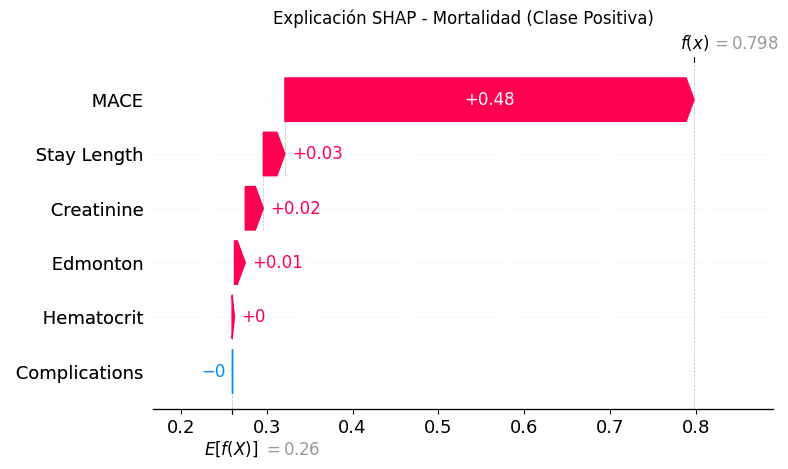

LIME EXPLANATION
Creatinine: +0.0874 ↑
Hematocrit: -0.0228 ↓
Stay Length: -0.0145 ↓
Edmonton: +0.0014 ↑
MACE: -0.0013 ↓
Complications: -0.0000 ↓


<Figure size 640x480 with 0 Axes>

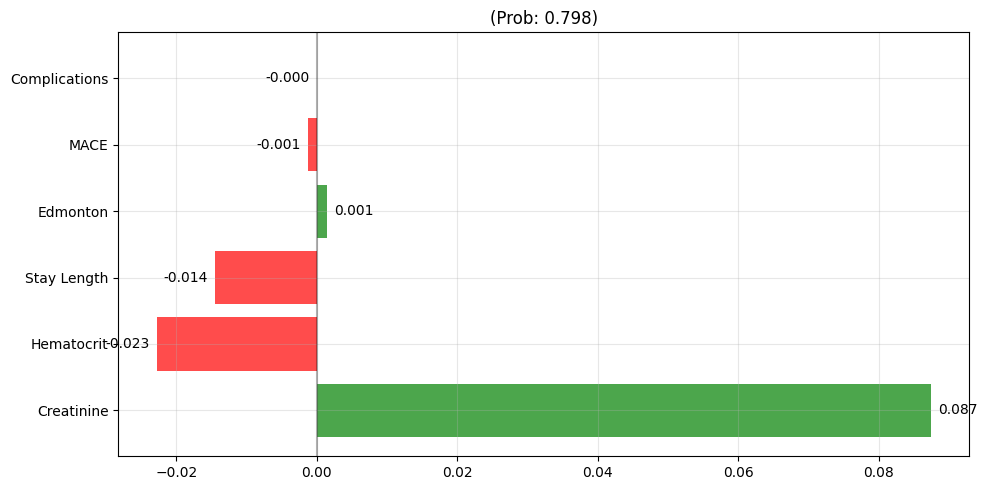

In [379]:
# Ejemplo de uso:
case_1 = {
    'Case': 'Paciente 1',
    'Creatininapre': 1.01,
    'Estanciahospitalariacalculada': 2.0,
    'Htopre': 34.2,
    'ComplicacionesMACE': 1.0,
    'ComplicacionesTODAS': 1.0,
    'Edmonton': 7.0
}

patient_description(case_1)
prediccion, shap_vals = shap_explanation(case_1, mostrar_clase_negativa=True)
prediccion, explanation = lime_explanation(case_1, class_positive=True)

DESCRIPCIÓN DEL PACIENTE
Case: True Negative
Creatininapre: 1.10
Estanciahospitalariacalculada: 9.00
Htopre: 41.30
ComplicacionesMACE: 0.00
ComplicacionesTODAS: 1.00
Edmonton: 6.00
SHAP EXPLANATION


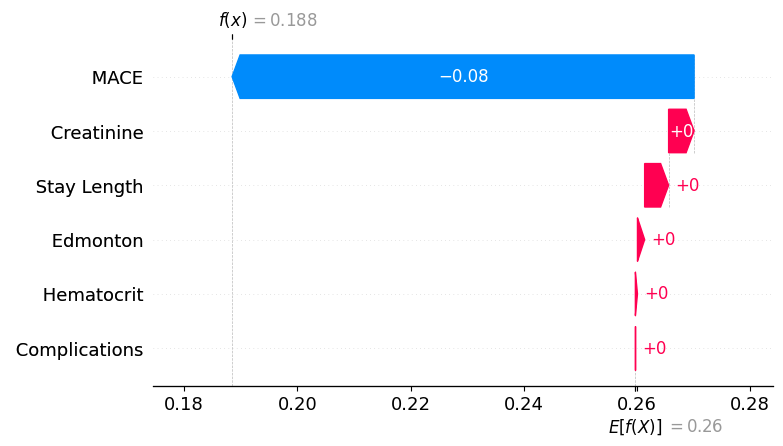

LIME EXPLANATION
Creatinine: +0.0793 ↑
Hematocrit: -0.0246 ↓
Stay Length: -0.0141 ↓
MACE: -0.0008 ↓
Complications: +0.0006 ↑
Edmonton: +0.0001 ↑


<Figure size 640x480 with 0 Axes>

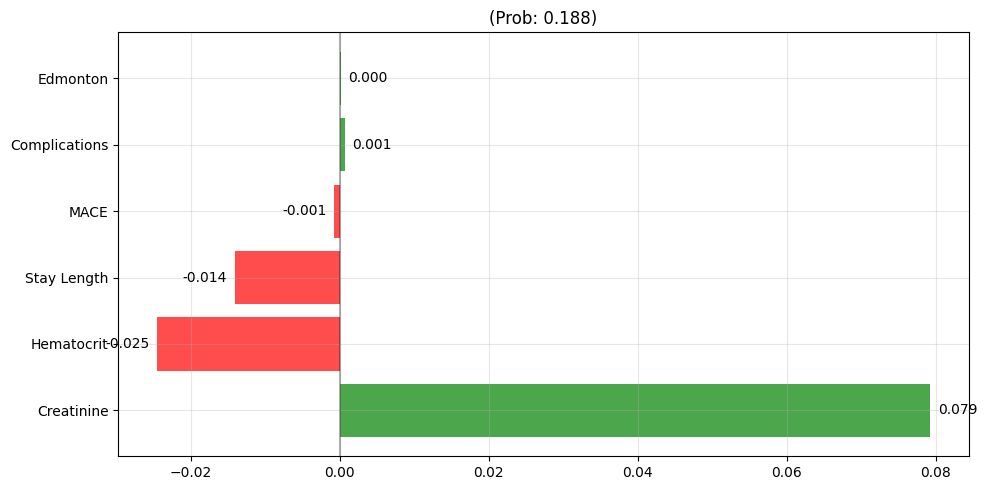

In [384]:
# Ejemplo de uso:
case_2 = {
    'Case': 'True Negative',
    'Creatininapre': 1.1,
    'Estanciahospitalariacalculada': 9.0,
    'Htopre': 41.3,
    'ComplicacionesMACE': 0.0,
    'ComplicacionesTODAS': 1.0,
    'Edmonton': 6.0
}

patient_description(case_2)
prediccion, shap_vals = shap_explanation(case_2, mostrar_clase_negativa=True)
prediccion, explanation = lime_explanation(case_2, class_positive=False)

DESCRIPCIÓN DEL PACIENTE
Case: False Positive
Creatininapre: 1.19
Estanciahospitalariacalculada: 21.00
Htopre: 29.10
ComplicacionesMACE: 1.00
ComplicacionesTODAS: 1.00
Edmonton: 2.00
SHAP EXPLANATION


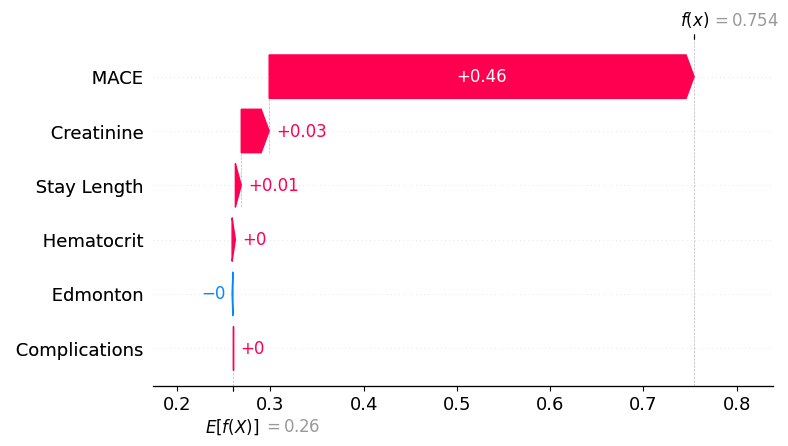

LIME EXPLANATION
Creatinine: +0.0740 ↑
Hematocrit: -0.0254 ↓
Stay Length: -0.0047 ↓
Edmonton: +0.0017 ↑
Complications: -0.0003 ↓
MACE: -0.0000 ↓


<Figure size 640x480 with 0 Axes>

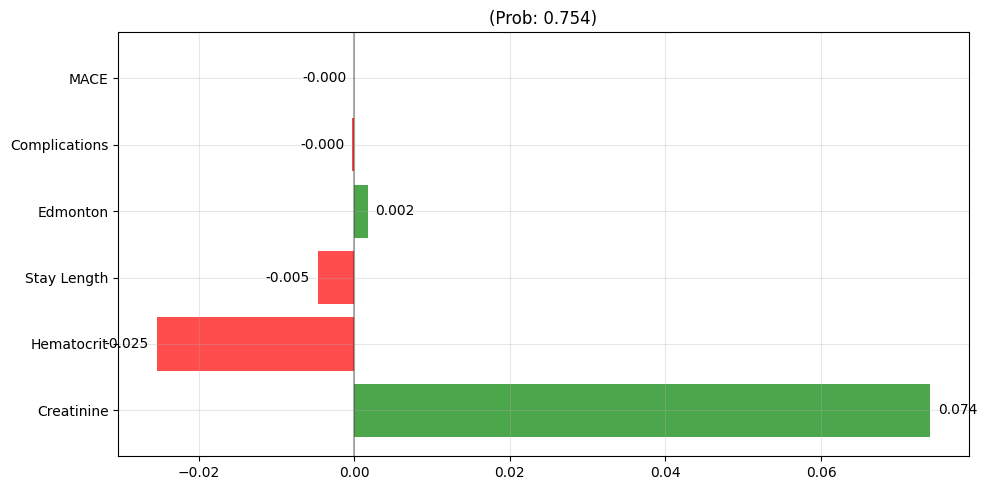

In [309]:
# Ejemplo de uso:
case_3 = {
    'Case': 'False Positive',
    'Creatininapre': 1.19,
    'Estanciahospitalariacalculada': 21.0,
    'Htopre': 29.1,
    'ComplicacionesMACE': 1.0,
    'ComplicacionesTODAS': 1.0,
    'Edmonton': 2.0
}

patient_description(case_3)
prediccion, shap_vals = shap_explanation(case_3, mostrar_clase_negativa=True)
prediccion, explanation = lime_explanation(case_3, class_positive=True)

DESCRIPCIÓN DEL PACIENTE
Case: False Negative
Creatininapre: 1.26
Estanciahospitalariacalculada: 7.00
Htopre: 38.90
ComplicacionesMACE: 0.00
ComplicacionesTODAS: 1.00
Edmonton: 6.00
SHAP EXPLANATION


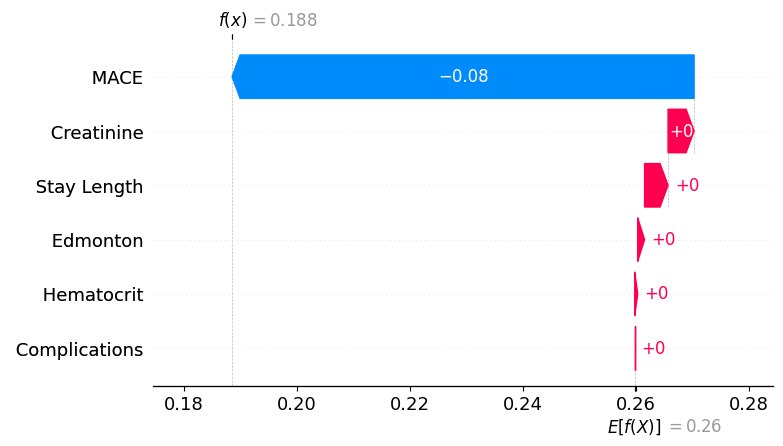

LIME EXPLANATION
Creatinine: +0.0711 ↑
Hematocrit: -0.0246 ↓
Stay Length: -0.0155 ↓
MACE: -0.0008 ↓
Complications: +0.0007 ↑
Edmonton: +0.0001 ↑


<Figure size 640x480 with 0 Axes>

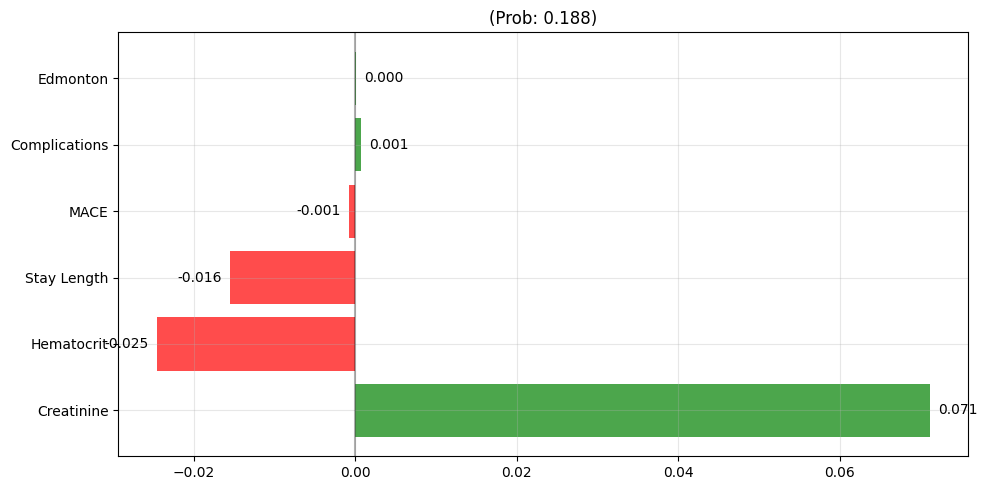

In [314]:
# Ejemplo de uso:
case_4 = {
    'Case': 'False Negative',
    'Creatininapre': 1.26,
    'Estanciahospitalariacalculada': 7.0,
    'Htopre': 38.9,
    'ComplicacionesMACE': 0.0,
    'ComplicacionesTODAS': 1.0,
    'Edmonton': 6.0
}

patient_description(case_4)
prediccion, shap_vals = shap_explanation(case_4, mostrar_clase_negativa=True)
prediccion, explanation = lime_explanation(case_4, class_positive=False)

DESCRIPCIÓN DEL PACIENTE
Case: Border Line Case
Creatininapre: 0.57
Estanciahospitalariacalculada: 11.00
Htopre: 34.80
ComplicacionesMACE: 1.00
ComplicacionesTODAS: 1.00
Edmonton: 4.00
SHAP EXPLANATION


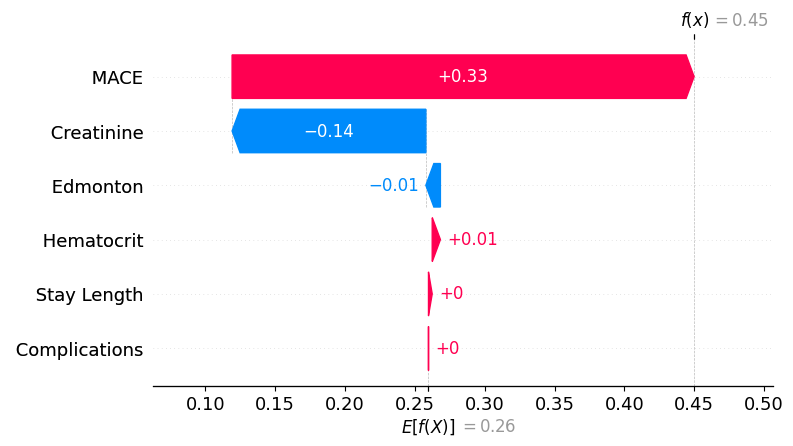

LIME EXPLANATION
Creatinine: +0.1058 ↑
Hematocrit: -0.0223 ↓
Stay Length: -0.0071 ↓
MACE: -0.0024 ↓
Edmonton: +0.0014 ↑
Complications: -0.0011 ↓


<Figure size 640x480 with 0 Axes>

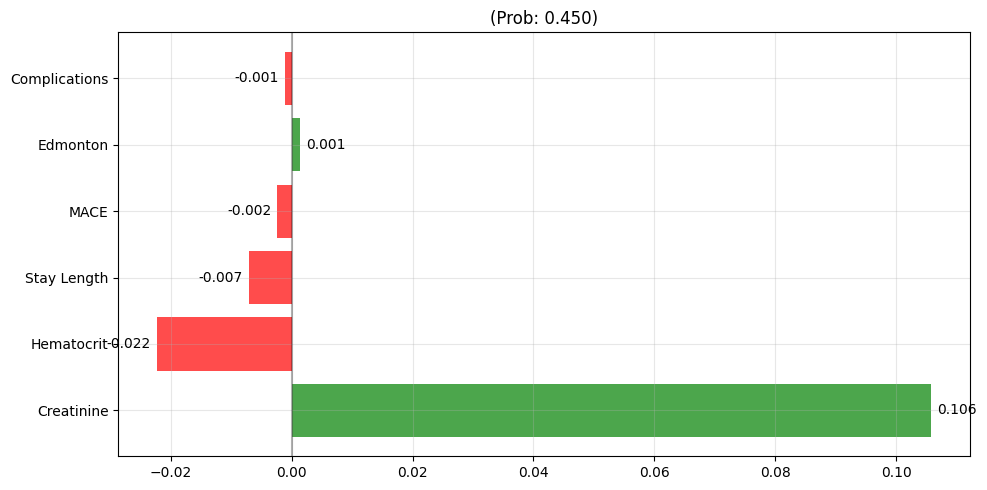

In [333]:
# Ejemplo de uso:
case_5 = {
    'Case': 'Border Line Case',
    'Creatininapre': 0.57,
    'Estanciahospitalariacalculada': 11.00,
    'Htopre': 34.8,
    'ComplicacionesMACE': 1.0,
    'ComplicacionesTODAS': 1.0,
    'Edmonton': 4.0
}

patient_description(case_5)
prediccion, shap_vals = shap_explanation(case_5, mostrar_clase_negativa=False)
prediccion, explanation = lime_explanation(case_5, class_positive=False)

In [334]:
id = 32
print(f"ID del paciente: {id}")
print("Descripción del paciente:")
for key, value in df.iloc[id].to_dict().items():
    print(f"{key}: {value}")

ID del paciente: 32
Descripción del paciente:
NHC: 628462
Edad: 75
Peso: 50
Talla: 158
SuperficieCorporal: 1.49
Género: 1
IMC: 20.03
DM: 0
DMdicotomica: 0
Tabaquismo: 0
TabaquismoDicot: 0
HTA: 0
DL: 0
Hipertrigliceridemia: 0
AFcar: 0
Arteriopatía: 0
Enfermedadcarotídea: 0
Obesidad: 0
Endocarditispreoperatoria: 0
EPOC: 0
EPOCdicot: 0
Hepatopatíaprevia: 0
Insuficienciarenalpreoperatoria: 0
Hbpre: 11.5
Htopre: 34.8
Leucograma: 5070
Linfocitos: 43.2
Monocitos: 4.9
Neutrofilos: 49.1
Eosinofilos: 2.2
Basofilos: 0.6
Plaq: 201
Creatininapre: 0.57
Proteinasatotales: 7.6
CK: 54
PCR: 0.7
Hiperuricemia: 0
IAMprevio: 0
EnfermedadTCI: 0
Numerovasosafectos: 0
ACVprevio: 0
Otrosantecedentes:  
Cateterismocardíaco: 1
Enfermedadcoronaria: 0
ACTPstentbypassprevio: 0
Reintervención: 0
CFNYHA: 3
EuroScoreI: 16.46
Euroscoreagrupado: 2
EuroScoreII: 6.5
EuroscoreIIagrupado: 2
TestFuerzaAgarre: 17
Test5metros: 17
Barthel: 100
Bartheldicotomica: 0
Katz: 6
Katzdicotomica: 0
Frail: 0
Fraildicotomica: 0
Edmonton: 